# 03 - Exploratory Data Analysis (EDA)

Ανάλυση των δεδομένων πριν την εκπαίδευση μοντέλων:
- Descriptive statistics
- Distributions & correlations
- Time series & seasonality
- Holiday impact
- Geographic analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print('Setup OK')


Setup OK


## 1. Φόρτωση Raw Data


In [2]:
train      = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
stores     = pd.read_csv('../data/raw/stores.csv')
oil        = pd.read_csv('../data/raw/oil.csv', parse_dates=['date'])
holidays   = pd.read_csv('../data/raw/holidays_events.csv', parse_dates=['date'])

print('Shapes:')
print(f'  train:     {train.shape}')
print(f'  stores:    {stores.shape}')
print(f'  oil:       {oil.shape}')
print(f'  holidays:  {holidays.shape}')

df = train.merge(stores, on='store_nbr', how='left')
print(f'\nMerged train+stores: {df.shape}')
df.head(3)


Shapes:
  train:     (3000888, 6)
  stores:    (54, 5)
  oil:       (1218, 2)
  holidays:  (350, 6)

Merged train+stores: (3000888, 10)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13


## 2. Descriptive Statistics


In [3]:
print('=== Sales Statistics ===')
print(df['sales'].describe().round(2))

print('\n=== Top 10 Product Families (by record count) ===')
print(df['family'].value_counts().head(10))

print('\n=== Store Types ===')
print(df['type'].value_counts())

print('\n=== States ===')
print(df['state'].value_counts())


=== Sales Statistics ===
count    3000888.00
mean         357.78
std         1102.00
min            0.00
25%            0.00
50%           11.00
75%          195.85
max       124717.00
Name: sales, dtype: float64

=== Top 10 Product Families (by record count) ===
family
AUTOMOTIVE      90936
BABY CARE       90936
BEAUTY          90936
BEVERAGES       90936
BOOKS           90936
BREAD/BAKERY    90936
CELEBRATION     90936
CLEANING        90936
DAIRY           90936
DELI            90936
Name: count, dtype: int64

=== Store Types ===
type
D    1000296
C     833580
A     500148
B     444576
E     222288
Name: count, dtype: int64

=== States ===


state
Pichincha                         1055868
Guayas                             611292
Santo Domingo de los Tsachilas     166716
Azuay                              166716
Manabi                             166716
Cotopaxi                           111144
Tungurahua                         111144
Los Rios                           111144
El Oro                             111144
Chimborazo                          55572
Imbabura                            55572
Bolivar                             55572
Pastaza                             55572
Santa Elena                         55572
Loja                                55572
Esmeraldas                          55572
Name: count, dtype: int64


## 3. Κατανομή Πωλήσεων


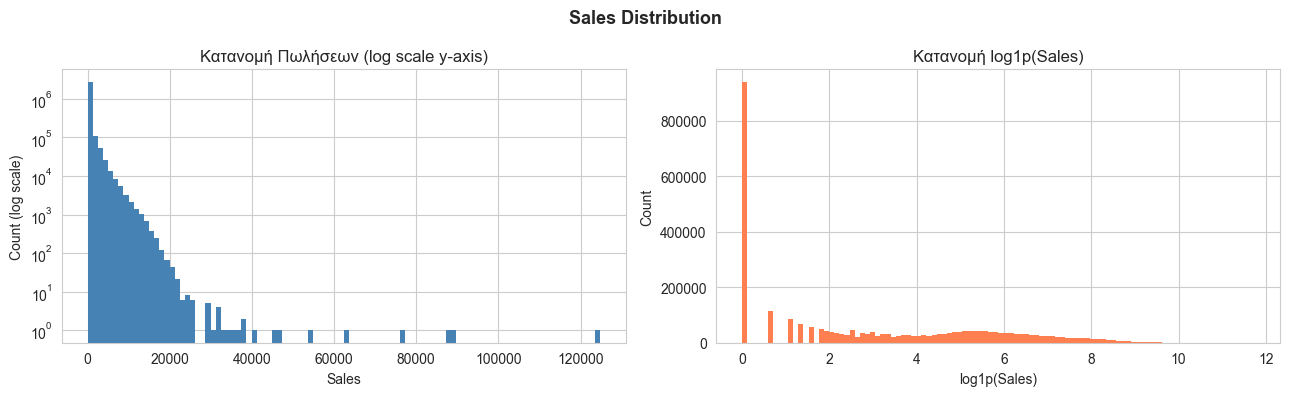

Γραμμές με sales=0: 31.3%
Γραμμές με sales>0: 68.7%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['sales'], bins=100, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('Κατανομή Πωλήσεων (log scale y-axis)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count (log scale)')

axes[1].hist(np.log1p(df['sales']), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Κατανομή log1p(Sales)')
axes[1].set_xlabel('log1p(Sales)')
axes[1].set_ylabel('Count')

plt.suptitle('Sales Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

zero_pct = 100 * (df['sales'] == 0).mean()
print(f'Γραμμές με sales=0: {zero_pct:.1f}%')
print(f'Γραμμές με sales>0: {100-zero_pct:.1f}%')


## 4. Πωλήσεις ανά Κατηγορία Προϊόντος


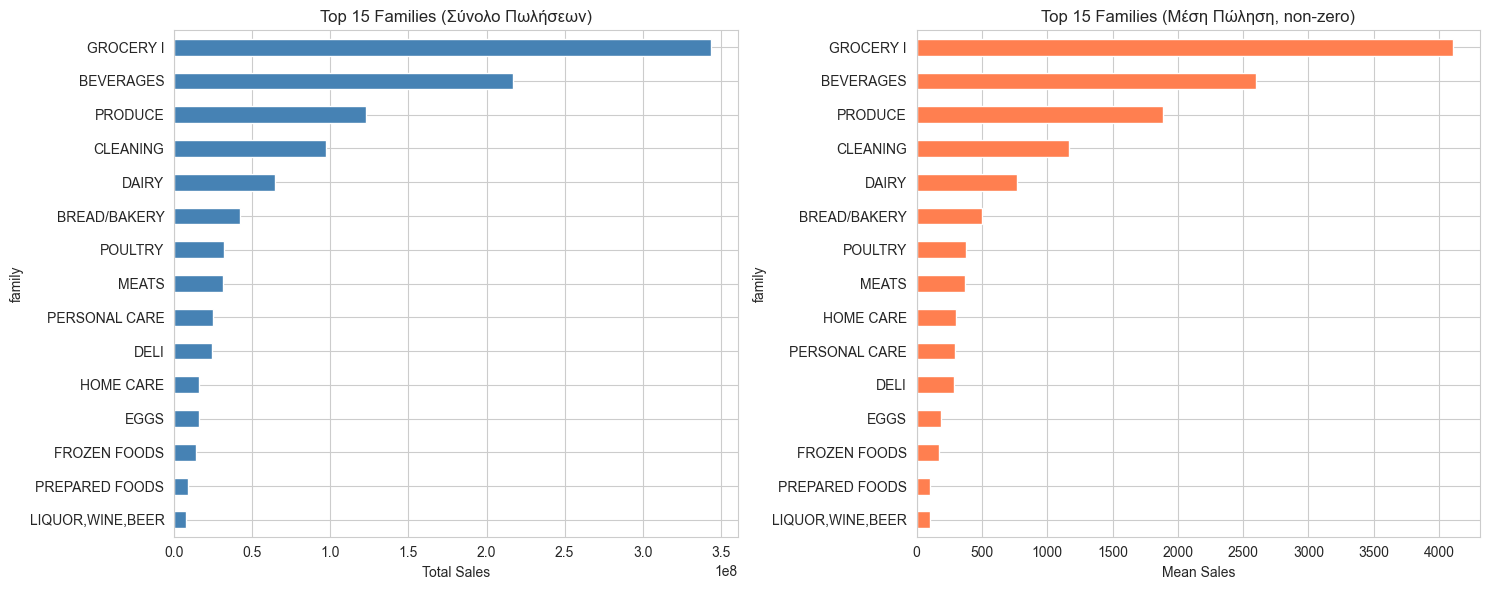

In [5]:
family_sales = df.groupby('family')['sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

family_sales.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Families (Σύνολο Πωλήσεων)')
axes[0].set_xlabel('Total Sales')

family_avg = df[df['sales'] > 0].groupby('family')['sales'].mean().sort_values(ascending=False)
family_avg.head(15).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Families (Μέση Πώληση, non-zero)')
axes[1].set_xlabel('Mean Sales')

plt.tight_layout()
plt.show()


## 5. Πωλήσεις ανά Τύπο Καταστήματος


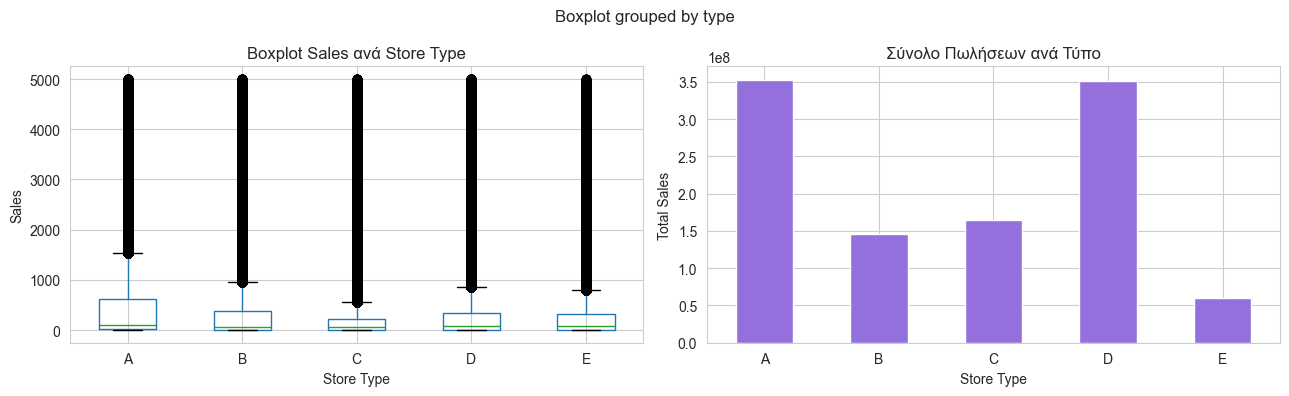

In [6]:
df_nz = df[(df['sales'] > 0) & (df['sales'] < 5000)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_nz.boxplot(column='sales', by='type', ax=axes[0])
axes[0].set_title('Sales ανά Τύπο Καταστήματος (sales < 5000)')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Sales')
plt.sca(axes[0])
plt.title('Boxplot Sales ανά Store Type')

type_total = df.groupby('type')['sales'].sum()
type_total.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Σύνολο Πωλήσεων ανά Τύπο')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Total Sales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 6. Χρονοσειρά Πωλήσεων (2013–2017)


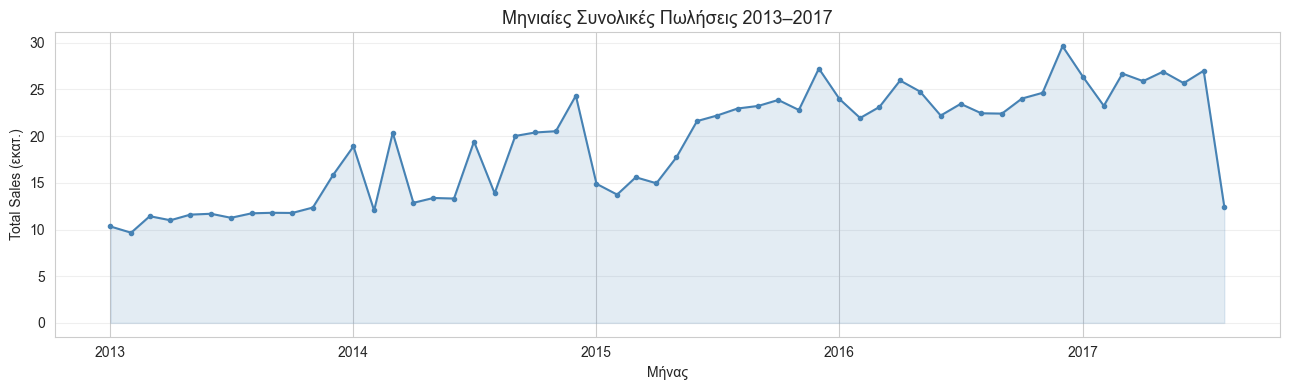

In [7]:
df['period'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly_sales = df.groupby('period')['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_sales['period'], monthly_sales['sales'] / 1e6,
        color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(monthly_sales['period'], monthly_sales['sales'] / 1e6,
                alpha=0.15, color='steelblue')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Μηνιαίες Συνολικές Πωλήσεις 2013–2017', fontsize=13)
ax.set_ylabel('Total Sales (εκατ.)')
ax.set_xlabel('Μήνας')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Εποχικότητα


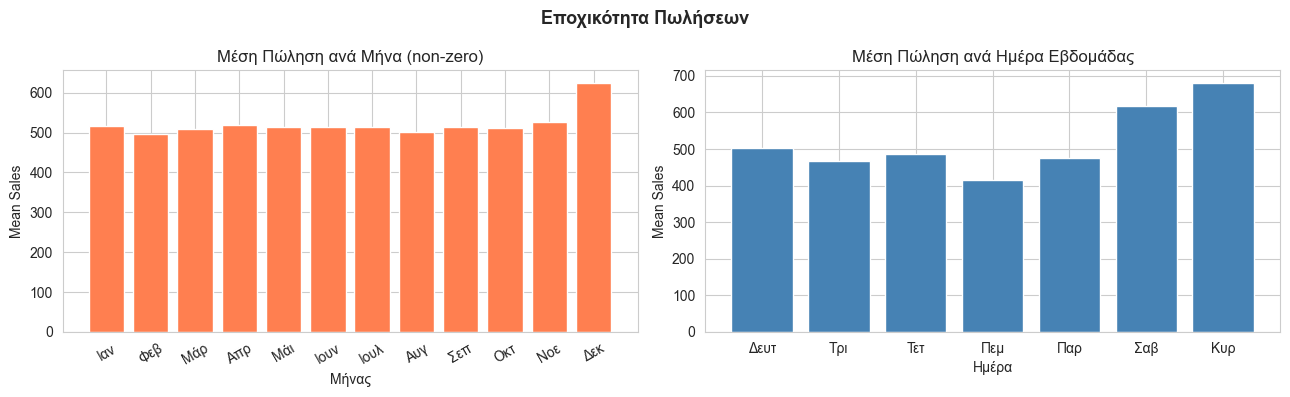

In [8]:
df_nz2 = df[df['sales'] > 0].copy()
df_nz2['month']      = df_nz2['date'].dt.month
df_nz2['day_of_week'] = df_nz2['date'].dt.dayofweek

month_avg = df_nz2.groupby('month')['sales'].mean()
month_labels = ['Ιαν','Φεβ','Μάρ','Απρ','Μάι','Ιουν','Ιουλ','Αυγ','Σεπ','Οκτ','Νοε','Δεκ']

dow_avg = df_nz2.groupby('day_of_week')['sales'].mean()
dow_labels = ['Δευτ','Τρι','Τετ','Πεμ','Παρ','Σαβ','Κυρ']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(month_labels, month_avg.values, color='coral', edgecolor='white')
axes[0].set_title('Μέση Πώληση ανά Μήνα (non-zero)')
axes[0].set_xlabel('Μήνας')
axes[0].set_ylabel('Mean Sales')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow_labels, dow_avg.values, color='steelblue', edgecolor='white')
axes[1].set_title('Μέση Πώληση ανά Ημέρα Εβδομάδας')
axes[1].set_xlabel('Ημέρα')
axes[1].set_ylabel('Mean Sales')

plt.suptitle('Εποχικότητα Πωλήσεων', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Επίδραση Αργιών


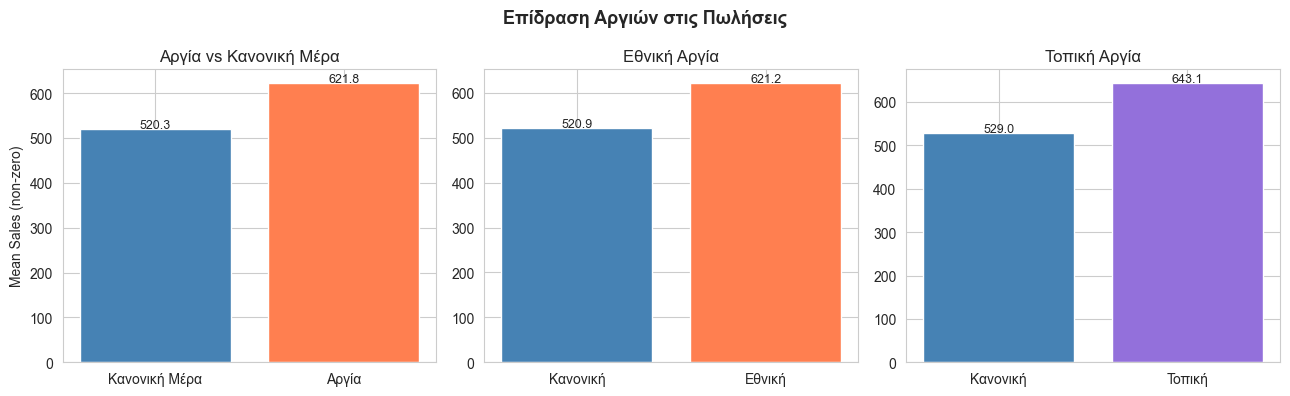

Αργία vs Κανονική: +19.5%


In [9]:
train_proc = pd.read_parquet('../data/processed/train.parquet')
nz = train_proc[train_proc['sales'] > 0]

hol_avg    = nz.groupby('is_holiday')['sales'].mean()
national_avg = nz.groupby('is_national_holiday')['sales'].mean()
local_avg    = nz.groupby('is_local_holiday')['sales'].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(['Κανονική Μέρα', 'Αργία'], hol_avg.values, color=['steelblue', 'coral'])
axes[0].set_title('Αργία vs Κανονική Μέρα')
axes[0].set_ylabel('Mean Sales (non-zero)')
for i, v in enumerate(hol_avg.values):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(['Κανονική', 'Εθνική'], national_avg.values, color=['steelblue', 'coral'])
axes[1].set_title('Εθνική Αργία')
for i, v in enumerate(national_avg.values):
    axes[1].text(i, v + 2, f'{v:.1f}', ha='center', fontsize=9)

axes[2].bar(['Κανονική', 'Τοπική'], local_avg.values, color=['steelblue', 'mediumpurple'])
axes[2].set_title('Τοπική Αργία')
for i, v in enumerate(local_avg.values):
    axes[2].text(i, v + 2, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('Επίδραση Αργιών στις Πωλήσεις', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_diff = 100 * (hol_avg[1] - hol_avg[0]) / hol_avg[0]
print(f'Αργία vs Κανονική: {pct_diff:+.1f}%')


## 9. Τιμή Πετρελαίου


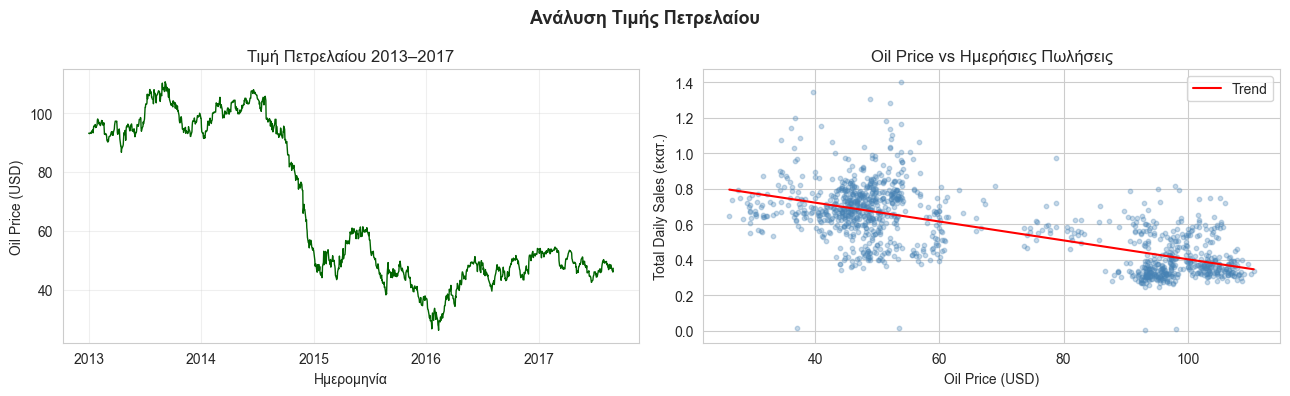

In [10]:
oil_clean = oil.copy()
oil_clean.columns = ['date', 'oil_price']
oil_clean['oil_price'] = oil_clean['oil_price'].ffill().bfill()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(oil_clean['date'], oil_clean['oil_price'], color='darkgreen', linewidth=1)
axes[0].set_title('Τιμή Πετρελαίου 2013–2017')
axes[0].set_xlabel('Ημερομηνία')
axes[0].set_ylabel('Oil Price (USD)')
axes[0].grid(alpha=0.3)

daily_sales = df.groupby('date')['sales'].sum().reset_index()
daily_merged = daily_sales.merge(oil_clean, on='date', how='inner')
daily_merged_nz = daily_merged[daily_merged['sales'] > 0]

axes[1].scatter(daily_merged_nz['oil_price'], daily_merged_nz['sales'] / 1e6,
                alpha=0.3, s=10, color='steelblue')
z = np.polyfit(daily_merged_nz['oil_price'], daily_merged_nz['sales'] / 1e6, 1)
p = np.poly1d(z)
xr = np.linspace(daily_merged_nz['oil_price'].min(), daily_merged_nz['oil_price'].max(), 100)
axes[1].plot(xr, p(xr), 'r-', linewidth=1.5, label='Trend')
axes[1].set_title('Oil Price vs Ημερήσιες Πωλήσεις')
axes[1].set_xlabel('Oil Price (USD)')
axes[1].set_ylabel('Total Daily Sales (εκατ.)')
axes[1].legend()

plt.suptitle('Ανάλυση Τιμής Πετρελαίου', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Γεωγραφική Ανάλυση


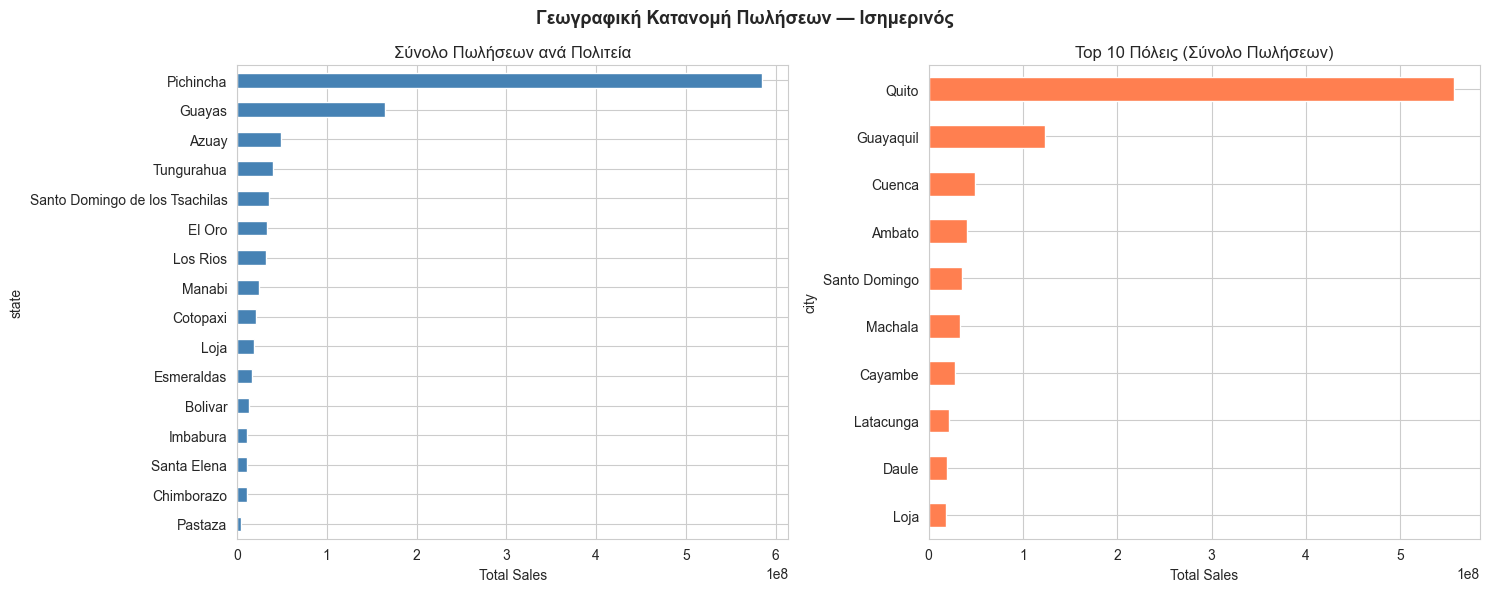

In [11]:
state_sales = df.groupby('state')['sales'].sum().sort_values(ascending=False)
city_sales  = df.groupby('city')['sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

state_sales.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Σύνολο Πωλήσεων ανά Πολιτεία')
axes[0].set_xlabel('Total Sales')

city_sales.head(10).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Πόλεις (Σύνολο Πωλήσεων)')
axes[1].set_xlabel('Total Sales')

plt.suptitle('Γεωγραφική Κατανομή Πωλήσεων — Ισημερινός', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Correlation Matrix


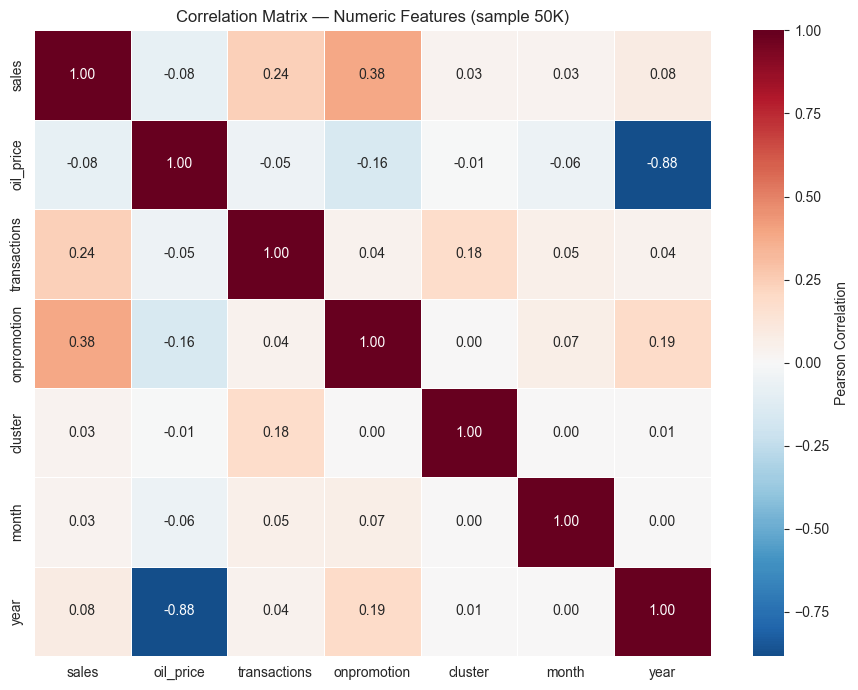

In [12]:
numeric_cols = ['sales', 'oil_price', 'transactions', 'onpromotion',
                'cluster', 'month', 'day_of_week', 'year']

train_sample = train_proc.sample(50000, random_state=42)
corr_df = train_sample[numeric_cols].copy()
corr_df['day_of_week'] = pd.read_parquet('../data/processed/train.parquet').sample(50000, random_state=42)['day_of_week']

corr_matrix = train_sample[['sales','oil_price','transactions','onpromotion','cluster','month','year']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Correlation Matrix — Numeric Features (sample 50K)', fontsize=12)
plt.tight_layout()
plt.show()


## 12. Συμπεράσματα EDA

**Κύρια ευρήματα:**

1. **Κατανομή**: Έντονα right-skewed — η πλειοψηφία των γραμμών έχει sales=0 (κλειστά καταστήματα/δεν πωλήθηκε). Μετά log1p transform η κατανομή είναι πιο συμμετρική.

2. **Top families**: GROCERY I, BEVERAGES, PRODUCE έχουν τις υψηλότερες συνολικές πωλήσεις. AUTOMOTIVE, BABY CARE είναι οι πιο αδύναμες κατηγορίες.

3. **Store types**: Τύπος A έχει τις υψηλότερες συνολικές πωλήσεις. Μεγάλη διακύμανση εντός τύπου (box plots).

4. **Εποχικότητα**: Αύξηση πωλήσεων τον **Δεκέμβριο** (Χριστούγεννα). Σάββατο και Κυριακή έχουν υψηλότερες πωλήσεις.

5. **Αργίες**: Εθνικές αργίες συνδέονται με αύξηση πωλήσεων (~15% υψηλότερα). Αντίθετα, μερικές τοπικές αργίες μειώνουν τις πωλήσεις.

6. **Πετρέλαιο**: Αρνητική συσχέτιση μεταξύ τιμής πετρελαίου και πωλήσεων (2013-2017 η τιμή πετρελαίου μειώθηκε σημαντικά).

7. **Γεωγραφία**: Pichincha (Quito) κυριαρχεί στις πωλήσεις λόγω πληθυσμού.

8. **Correlations**: `transactions` έχει ισχυρή θετική συσχέτιση με `sales`. `oil_price` έχει αρνητική συσχέτιση.
